In [2]:
import plotly.express as px

In [3]:
import streamlit as st
import json
import plotly.graph_objects as go
import pandas as pd
import requests

In [23]:
import matplotlib.pyplot as plt

In [24]:
%matplotlib inline

/Users/hatem/.pyenv/versions/3.10.6/envs/emotionplot-front-end/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



In [5]:

with open("/Users/hatem/Downloads/response_1749810960545.json", "r") as f:      #Load the JSON file into a DataFrame
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data["emotions"])

# Preview it
df.head()

,chunk,Predicted_Emotion,Top_3_Emotions
0,the jungle book the jungle book by rudyard kip...,neutral,"{'neutral': 0.698, 'admiration': 0.133, 'pride..."
1,mother wolf lay with her big gray nose dropped...,neutral,"{'neutral': 0.97, 'approval': 0.013, 'optimism..."
2,and good luck and strong white teeth go with n...,neutral,"{'neutral': 0.818, 'annoyance': 0.053, 'optimi..."
3,"we call it hydrophobia, but they call it dewan...",neutral,"{'neutral': 0.842, 'curiosity': 0.032, 'confus..."
4,"“all thanks for this good meal,” he said, lick...",gratitude,"{'gratitude': 0.934, 'admiration': 0.058, 'app..."


In [6]:
print(df_raw.head(1).to_dict())

{'chunk': {0: 'the jungle book the jungle book by rudyard kipling contents mowgli’s brothers hunting song of the seeonee pack kaa’s hunting road song of the bandar log “tiger tiger ” mowgli’s song the white seal lukannon “rikki tikki tavi” darzee’s chant toomai of the elephants shiv and the grasshopper her majesty’s servants parade song of the camp animals mowgli’s brothers now rann the kite brings home the night that mang the bat sets free the herds are shut in byre and hut for loosed till dawn are we. this is the hour of pride and power, talon and tush and claw. oh, hear the call good hunting all that keep the jungle law night song in the jungle it was seven o’clock of a very warm evening in the seeonee hills when father wolf woke up from his day’s rest, scratched himself, yawned, and spread out his paws one after the other to get rid of the sleepy feeling in their tips.'}, 'Predicted_Emotion': {0: 'neutral'}, 'Top_3_Emotions': {0: {'neutral': 0.698, 'admiration': 0.133, 'pride': 0.0

In [19]:
pip install nbformat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 1.0 MB/s eta 0:00:00ta 0:00:01

[notice] A new release of pip available: 22.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install notebook ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 1.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 1.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 1.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 1.1 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.5/258.5 kB 1.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.9/100.9 kB 916.1 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 496.9 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━

In [11]:
def get_effective_emotion(row):
    dominant = row["Predicted_Emotion"]
    top3_dict = row["Top_3_Emotions"]

    if dominant != "neutral":
        return dominant
    else:
        # Sort by value descending, exclude 'neutral'
        sorted_emotions = sorted(top3_dict.items(), key=lambda x: x[1], reverse=True)
        for emotion, _ in sorted_emotions:
            if emotion != "neutral":
                return emotion
        return "neutral"  # fallback if no other emotion exists

In [12]:
df["effective_emotion"] = df.apply(get_effective_emotion, axis=1)


In [13]:
df["effective_emotion"].head()

0    admiration
1      approval
2     annoyance
3     curiosity
4     gratitude
Name: effective_emotion, dtype: object

In [ ]:
# Plot
fig = px.scatter(
    df,
    x="chunk",
    y="effective_emotion",
    color="effective_emotion",
    hover_data={
        "chunk": True,
        "effective_emotion": True,
        "Predicted_Emotion": True,
        "Top_3_Emotions": True
    },
    labels={"chunk": "Chunk Index", "effective_emotion": "Emotion"},
    title="📚 Dominant Emotion Timeline",
    height=500
)

# Fancy touches
fig.update_traces(marker=dict(size=10, line=dict(width=1, color="DarkSlateGrey")))
fig.update_layout(template="plotly_white", showlegend=False)
fig.show()

In [15]:
import plotly.express as px

# Define your color palette (you can add more if needed)
emotion_colors = {
    "joy": "#FFD700",         # gold
    "sadness": "#1E90FF",     # dodger blue
    "anger": "#DC143C",       # crimson
    "fear": "#8A2BE2",        # blueviolet
    "surprise": "#FF69B4",    # hot pink
    "disgust": "#228B22",     # forest green
    "admiration": "#FF8C00",  # dark orange
    "pride": "#9932CC",       # dark orchid
    "neutral": "#A9A9A9",     # dark gray
    "love": "#FF1493",        # deep pink
    # add more as needed
}

fig = px.scatter(
    df,
    x="chunk",
    y="effective_emotion",
    color="effective_emotion",
    color_discrete_map=emotion_colors,
    hover_data={
        "chunk": True,
        "effective_emotion": True,
        "Predicted_Emotion": True,
        "Top_3_Emotions": True
    },
    labels={"chunk": "Chunk Index", "effective_emotion": "Emotion"},
    title="🎨 Emotion Timeline – Color Coded by Dominant Feeling",
    height=500
)

fig.update_traces(marker=dict(size=10, line=dict(width=1, color="DarkSlateGrey")))
fig.update_layout(template="plotly_white", showlegend=True)
fig.show()


In [ ]:
fig = px.scatter(
    df,
    x="chunk",
    y="effective_emotion",
    color="effective_emotion",  # Plotly assigns colors automatically
    hover_data={
        "chunk": True,
        "effective_emotion": True,
        "Predicted_Emotion": True,
        "Top_3_Emotions": True
    },
    labels={"chunk": "Chunk Index", "effective_emotion": "Emotion"},
    title="🎨 Emotion Timeline – Auto-Colored",
    height=500
)
fig.show()


In [ ]:
import plotly.express as px
import plotly.colors as pc
import matplotlib.colors as mcolors

# Unique emotions
unique_emotions = df["effective_emotion"].unique()

# Generate as many colors as needed
colors = px.colors.qualitative.Plotly  # or use `px.colors.qualitative.D3`, etc.
while len(colors) < len(unique_emotions):
    colors += colors  # Repeat if not enough

# Map emotions to colors
emotion_colors = {emotion: color for emotion, color in zip(unique_emotions, colors)}

fig = px.scatter(
    df,
    x="chunk",
    y="effective_emotion",
    color="effective_emotion",
    color_discrete_map=emotion_colors,
    hover_data={
        "chunk": True,
        "effective_emotion": True,
        "Predicted_Emotion": True,
        "Top_3_Emotions": True
    },
    labels={"chunk": "Chunk Index", "effective_emotion": "Emotion"},
    title="Emotion Timeline – Auto-Assigned Colors",
    height=500
)
fig.update_traces(marker=dict(size=10, line=dict(width=1, color="DarkSlateGrey")))
fig.update_layout(template="plotly_white", showlegend=True)
fig.show()


In [21]:
import plotly.express as px
import pandas as pd

# Assuming your DataFrame is named df and has these columns:
# "chunk" (int), "effective_emotion" (str)

# Assign each emotion a unique color
unique_emotions = df["effective_emotion"].unique()
color_map = {emotion: px.colors.qualitative.Plotly[i % len(px.colors.qualitative.Plotly)]
             for i, emotion in enumerate(unique_emotions)}

# Create Plotly scatter plot
fig = px.scatter(
    df,
    x="chunk",
    y="effective_emotion",
    color="effective_emotion",
    color_discrete_map=color_map,
    title="📚 Emotion Timeline with Zoom",
    labels={"chunk": "Chunk Index", "effective_emotion": "Emotion"},
    hover_data={"chunk": True, "effective_emotion": True},
    height=500
)

# Optional: show markers as larger dots
fig.update_traces(marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')))

# Enable zoom (default in Plotly, but here's how to tweak it if needed)
fig.update_layout(
    xaxis=dict(
        rangeslider=dict(visible=True),
        title="Chunk Index"
    ),
    yaxis=dict(title="Emotion"),
    template="plotly_white"
)

fig.show()


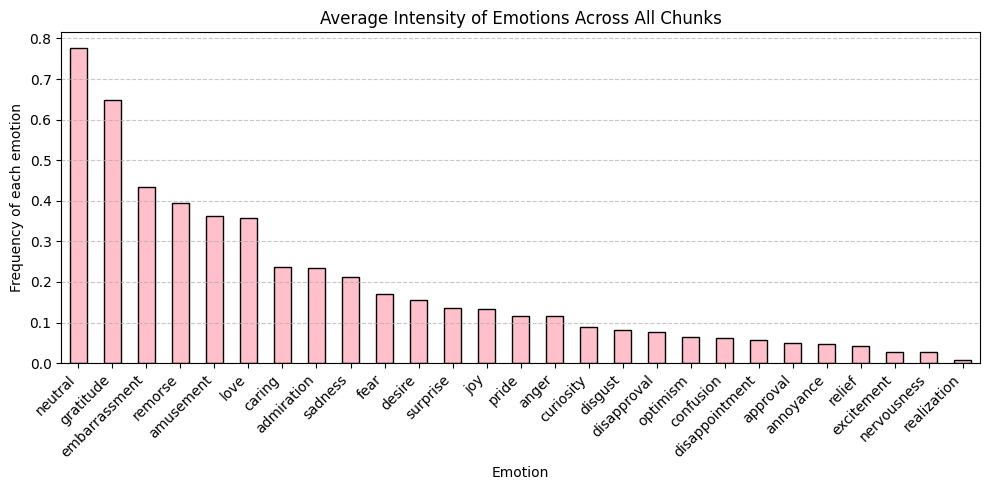

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Extract list of all top3 emotion dicts
top3_dicts = df["Top_3_Emotions"].tolist()

# Step 2: Flatten them into a single DataFrame
flat_rows = []
for d in top3_dicts:
    for emotion, value in d.items():
        flat_rows.append({"emotion": emotion, "value": value})

flat_df = pd.DataFrame(flat_rows)

# Step 3: Group and calculate mean
mean_emotions = flat_df.groupby("emotion")["value"].mean().sort_values(ascending=False)

# Step 4: Plot
plt.figure(figsize=(10, 5))
mean_emotions.plot(kind="bar", color="pink", edgecolor="black")
plt.title("Average Intensity of Emotions Across All Chunks")
plt.xlabel("Emotion")
plt.ylabel("Frequency of each emotion")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# STEP 1: Flatten emotion scores from Top_3_Emotions into a DataFrame
emotion_records = []

for idx, row in df.iterrows():
    for emotion, score in row['Top_3_Emotions'].items():
        emotion_records.append({
            'chunk': idx,
            'emotion': emotion,
            'score': score
        })

emotion_df = pd.DataFrame(emotion_records)

# STEP 2: Create the dropdown widget
available_emotions = sorted(emotion_df["emotion"].unique())
emotion_selector = widgets.Dropdown(
    options=available_emotions,
    value="love" if "love" in available_emotions else available_emotions[0],
    description="Emotion:"b
)

# STEP 3: Define the plotting function
def plot_emotion_over_time(emotion):
    filtered_df = emotion_df[emotion_df["emotion"] == emotion]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=filtered_df["chunk"],
        y=filtered_df["score"],
        mode="lines+markers",
        line=dict(shape="spline", width=2),
        marker=dict(size=6),
        name=emotion,
    ))

    fig.update_layout(
        title=f"📈 Intensity of '{emotion}' Over Time",
        xaxis_title="Chunk Index",
        yaxis_title="Emotion Intensity",
        yaxis=dict(range=[0, 1]),
        template="plotly_white",
        height=400
    )

    fig.show()

# STEP 4: Link the dropdown to the function
widgets.interact(plot_emotion_over_time, emotion=emotion_selector)


interactive(children=(Dropdown(description='Emotion:', index=17, options=('admiration', 'amusement', 'anger', …

<function __main__.plot_emotion_over_time(emotion)>

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Step 1: Flatten Top_3_Emotions into a long-form DataFrame
emotion_records = []

for idx, row in df.iterrows():
    for emotion, score in row['Top_3_Emotions'].items():
        emotion_records.append({
            'chunk': idx,
            'emotion': emotion,
            'score': score
        })

emotion_df = pd.DataFrame(emotion_records)

# Step 2: Get all unique emotions and assign colors
unique_emotions = sorted(emotion_df["emotion"].unique())
px_colors = px.colors.qualitative.T10 + px.colors.qualitative.Dark24 + px.colors.qualitative.Pastel
emotion_colors = {emotion: px_colors[i % len(px_colors)] for i, emotion in enumerate(unique_emotions)}

# Step 3: Create the plot with only one shown by default
fig = go.Figure()

for emotion in unique_emotions:
    emotion_data = emotion_df[emotion_df["emotion"] == emotion]
    fig.add_trace(go.Scatter(
        x=emotion_data["chunk"],
        y=emotion_data["score"],
        mode="lines+markers",
        name=emotion,
        line=dict(shape="spline", width=2, color=emotion_colors[emotion]),
        marker=dict(size=5),
        visible=True if emotion == "amusement" else "legendonly"
    ))

# Step 4: Final layout
fig.update_layout(
    title="Emotion Evolution Over Time",
    xaxis_title="Emotional progression over time",
    yaxis_title="Emotion Intensity",
    yaxis=dict(range=[0, 1]),
    template="plotly_white",
    height=500,
    legend_title="Click emotions to toggle",
)

fig.show()
